In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [3]:
x=sp.symbols('x',real=True)
s=sp.symbols('s',positive=True)
gam=sp.Integral(sp.E**(-x)*x**(s-1),(x,0,sp.oo))
gam

Integral(x**(s - 1)*exp(-x), (x, 0, oo))

In [22]:
sp.factorial(6)

720

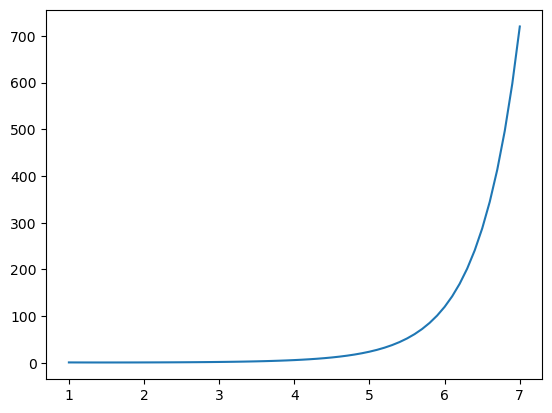

In [23]:
ix=np.arange(1,7.1,0.1)
iy=[gam.subs(s,_).doit() for _ in ix]
plt.plot(ix,iy)

In [27]:
# 卡方分布
v=sp.symbols('v',positive=True)
fx=1/(2**(v/2)*sp.gamma(v/2))*x**(v/2-1)*sp.E**(-x/2)
sp.simplify(sp.Integral(fx,(x,0,sp.oo)).doit())

1

<lambdifygenerated-25>:2: RuntimeWarning: divide by zero encountered in divide
  return (1/2)*sqrt(2)*exp(-1/2*x)/(sqrt(pi)*sqrt(x))
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21345 (\N{CJK UNIFIED IDEOGRAPH-5361}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21345 (\N{CJK UNIFIED ID

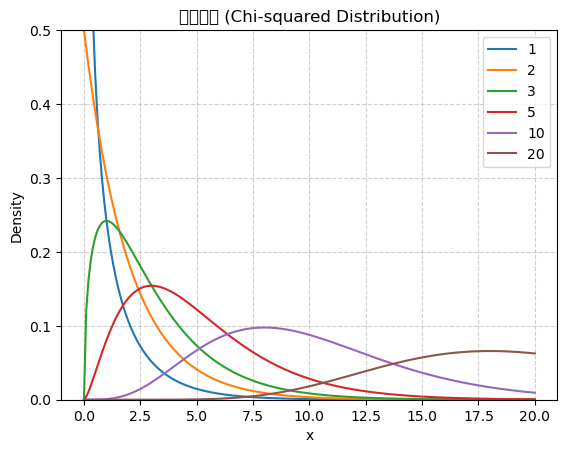

In [49]:
from cProfile import label


ix=np.linspace(0,20,201)
# fxi=sp.Integral(fx,(x,0,x))

for _ in (1,2,3,5,10,20):
    f_s=fx.subs(v,_)
    ff=sp.lambdify(x,f_s)

    plt.plot(ix,ff(ix),label=f'{_}')

plt.title('卡方分布 (Chi-squared Distribution)')
plt.ylim(0, 0.5) # 限制 Y 轴范围，让不同自由度的曲线对比更清晰
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)